# EDA

In [26]:
# Imports

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath(".."))

from preprocessing import get_X_y

In [3]:
# Data Load

df = pd.read_csv(r"..\dataset\KAG_energydata_complete.csv")

df

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,...,17.033333,45.5300,6.600000,733.5,92.000000,7.000000,63.000000,5.300000,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,...,17.066667,45.5600,6.483333,733.6,92.000000,6.666667,59.166667,5.200000,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,...,17.000000,45.5000,6.366667,733.7,92.000000,6.333333,55.333333,5.100000,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,...,17.000000,45.4000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000,10.084097,10.084097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,2016-05-27 17:20:00,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,...,23.200000,46.7900,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,43.096812,43.096812
19731,2016-05-27 17:30:00,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,...,23.200000,46.7900,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,49.282940,49.282940
19732,2016-05-27 17:40:00,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,...,23.200000,46.7900,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,29.199117,29.199117
19733,2016-05-27 17:50:00,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,...,23.200000,46.8175,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,6.322784,6.322784


In [4]:
# Stats

df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [5]:
# Null Values

print(df.isnull().sum())

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


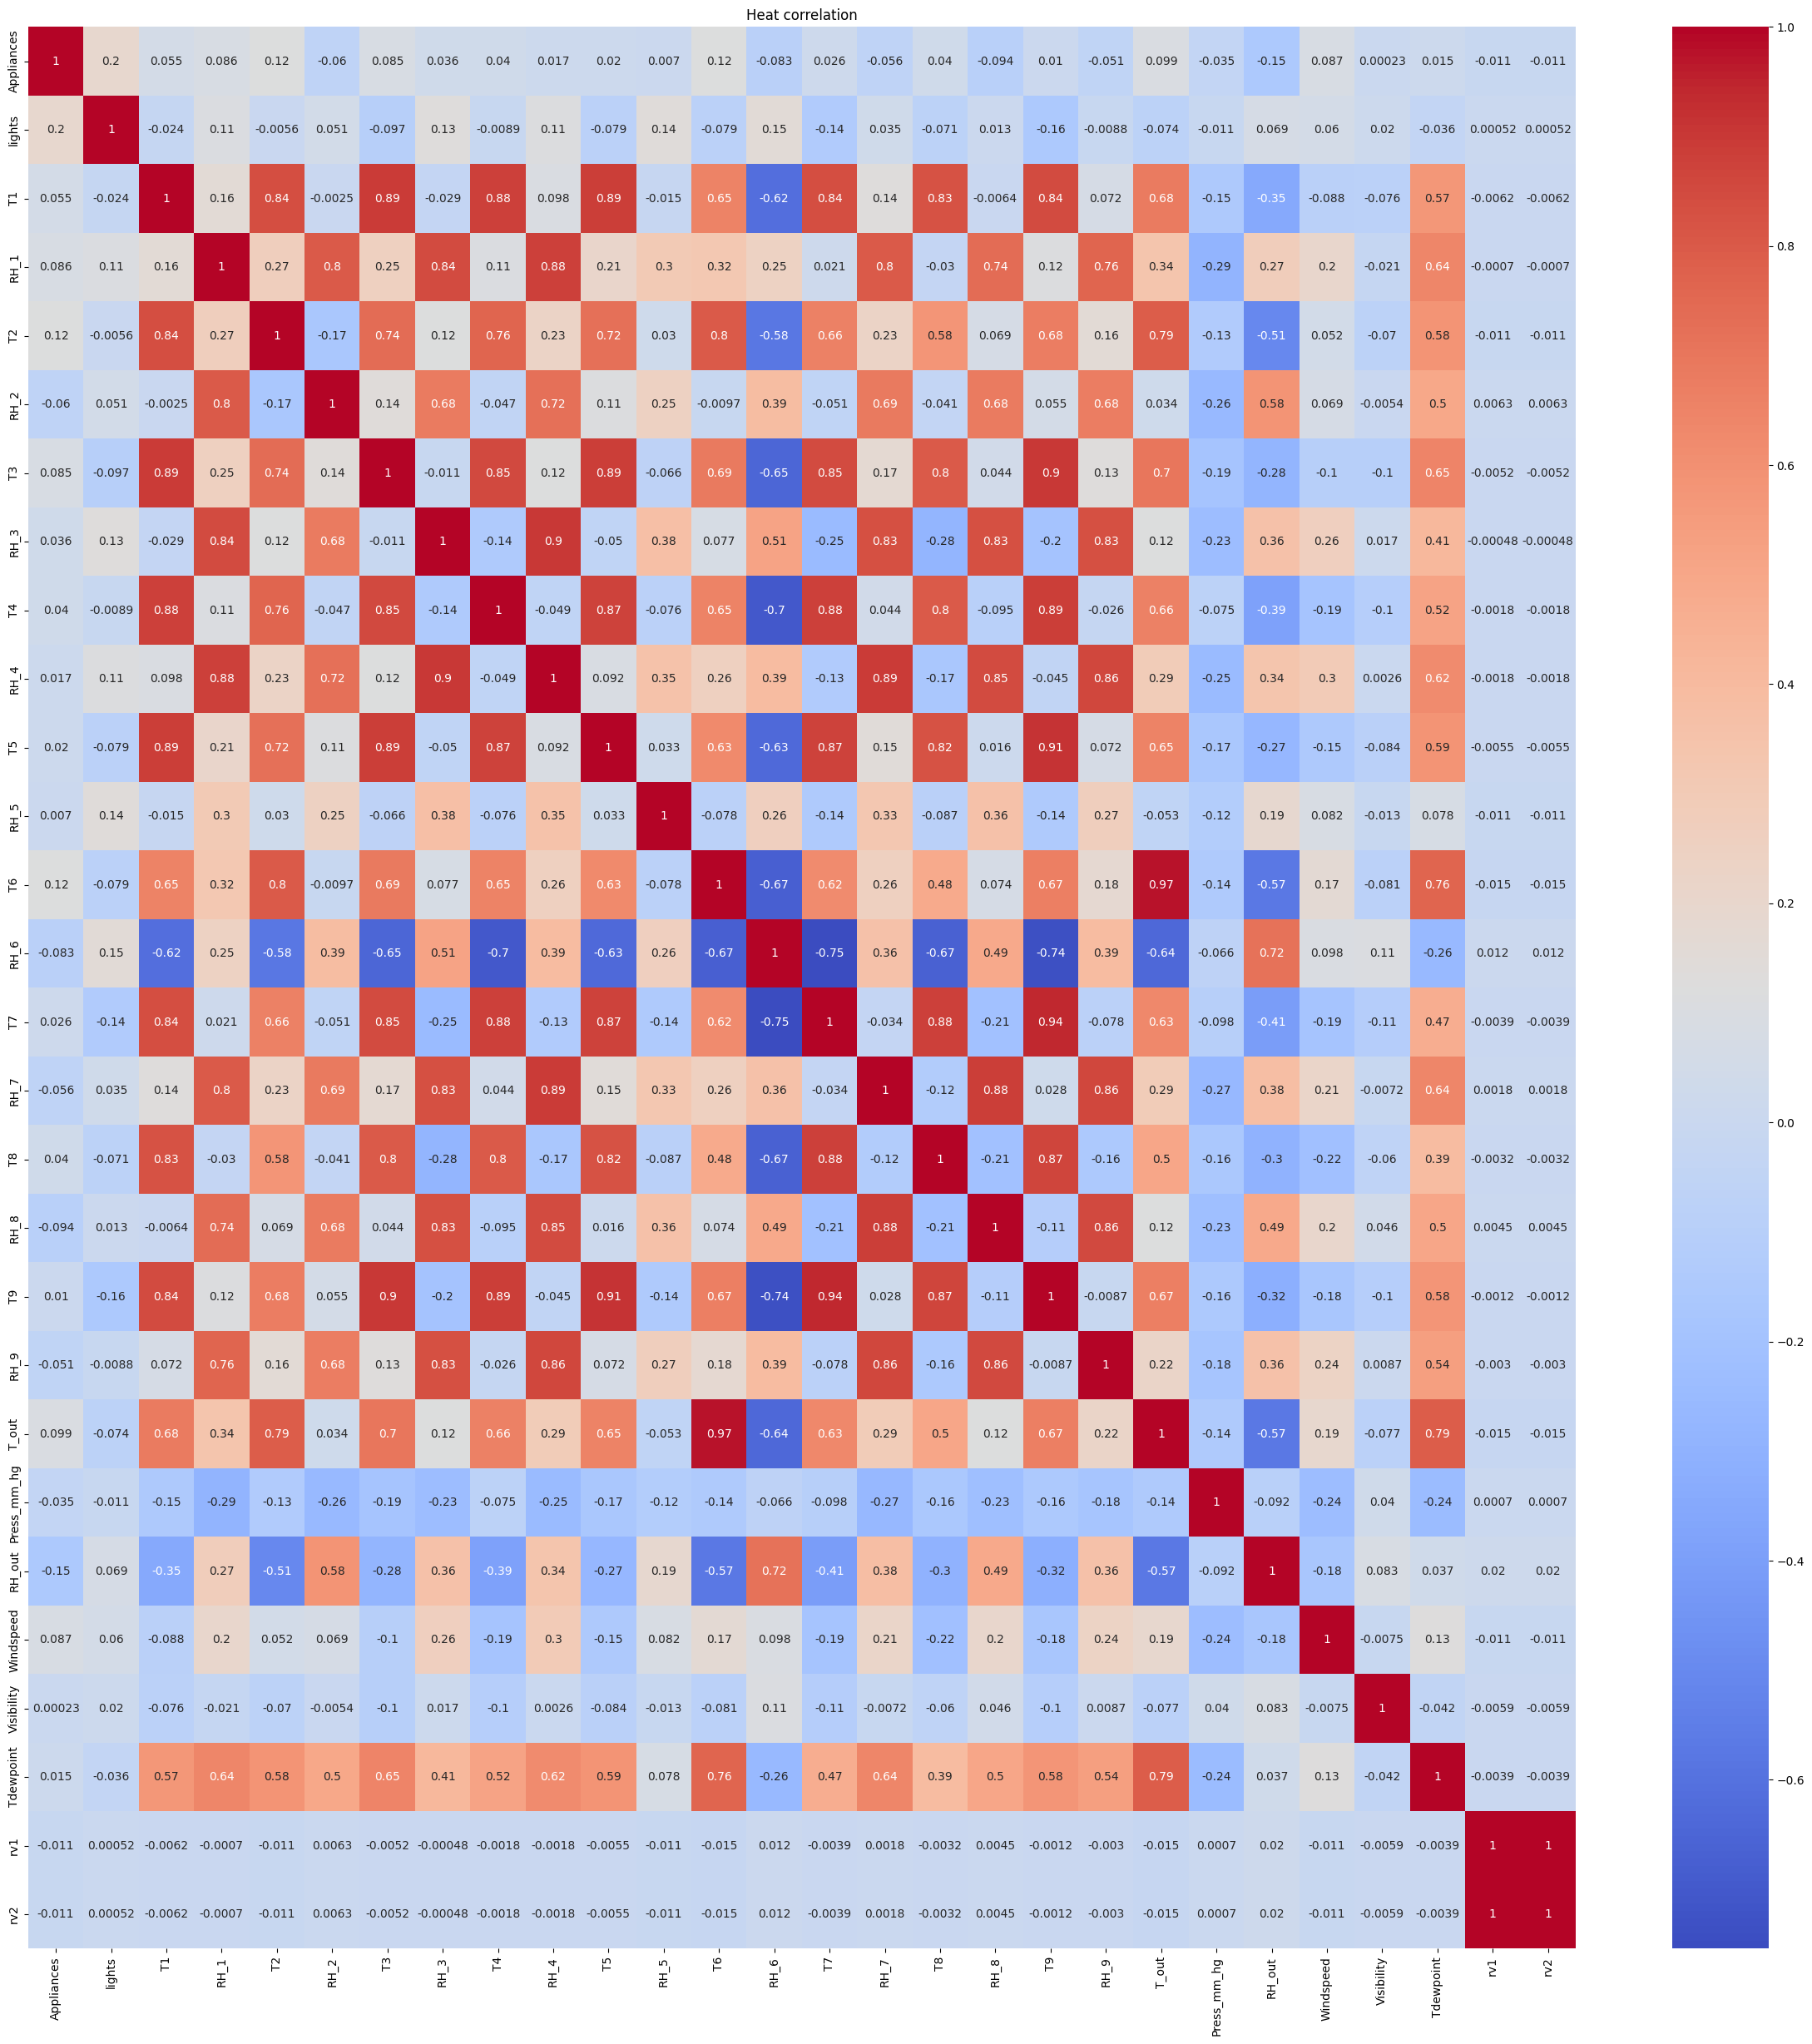

In [6]:
# Heat Map
plt.figure(figsize=(30 , 30))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Heat correlation")
plt.show()

# lights has the strongest direct relationship with Appliances
# No feature alone explains the target
# Heavy Multicollinearity in some features
# rv1 and rv2 are Junk

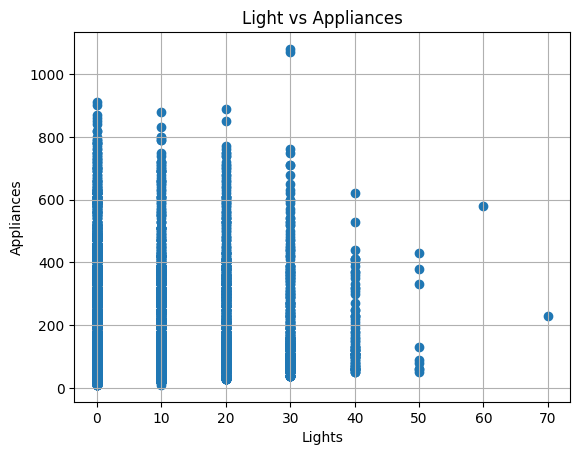

In [7]:
# Light vs Appliances

plt.scatter(df["lights"] , df["Appliances"])

plt.xlabel("Lights")
plt.ylabel("Appliances")
plt.title("Light vs Appliances")
plt.grid()
plt.show()

# In this dataset the value of light is discrete and this feature alone cannot explain the y

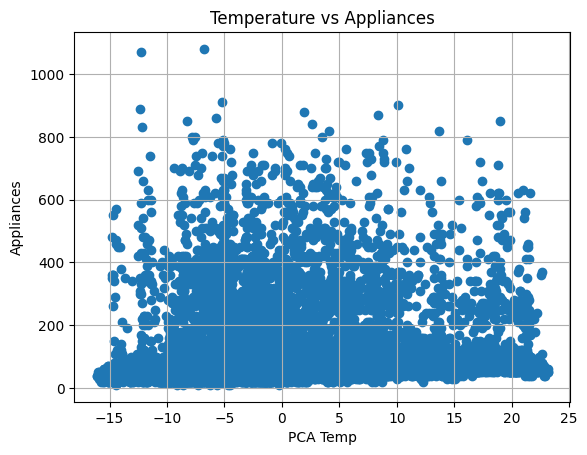

In [8]:
# Temperature vs Appliances

pca = PCA(n_components = 1)

arr_temp_pca = pca.fit_transform(df[["T1" , "T2" , "T3" , "T4" , "T5" , "T6" , "T7" , "T8" , "T9"]])
df_temp_pca = pd.DataFrame(arr_temp_pca , columns = ["T_PCA"])

plt.scatter(df_temp_pca["T_PCA"] , df["Appliances"])

plt.xlabel("PCA Temp")
plt.ylabel("Appliances")
plt.title("Temperature vs Appliances")
plt.grid()
plt.show()

# PCA was applied to combine nine highly correlated temperature sensors into a single principal component. Scatter plot analysis showed no strong direct relationship between the temperature component and appliance energy consumption, indicating that appliance usage is influenced by multiple factors rather than temperature alone.

In [27]:
# Chacking Feature Importance (No preprocessing)

X = df.drop(["date" , "Appliances"] , axis = 1)
y = df["Appliances"]
EDA_model = RandomForestRegressor().fit(X , y)

feature_imp = pd.Series(EDA_model.feature_importances_ , index= X.columns).sort_values(ascending=False)

print(feature_imp)

RH_out         0.063292
RH_1           0.056544
Press_mm_hg    0.050543
RH_3           0.050233
RH_8           0.048307
T3             0.048265
RH_2           0.047151
lights         0.046386
RH_5           0.046073
T8             0.040659
RH_6           0.040463
RH_7           0.037199
T4             0.035345
T2             0.035233
RH_4           0.034649
RH_9           0.033577
T5             0.032745
T6             0.031181
T1             0.030026
Tdewpoint      0.029559
T9             0.028555
Windspeed      0.028038
T7             0.026900
T_out          0.024179
Visibility     0.020377
rv1            0.017973
rv2            0.016551
dtype: float64


In [28]:
# Chacking Feature Importance (Preprocessed)

X , y = get_X_y(df)

EDA_model = RandomForestRegressor().fit(X , y)

feature_imp = pd.Series(EDA_model.feature_importances_ , index= X.columns).sort_values(ascending=False)

print(feature_imp)

Hour           0.149888
T3             0.057220
RH_3           0.048273
Press_mm_hg    0.042950
RH_5           0.040289
RH_2           0.037799
T8             0.037308
RH_1           0.034106
Tdewpoint      0.033444
RH_7           0.032907
RH_4           0.032085
RH_8           0.030823
RH_out         0.030576
lights         0.030234
T4             0.029550
T2             0.028806
RH_6           0.028770
RH_9           0.028516
T5             0.028094
Windspeed      0.026899
T_out          0.026401
T6             0.026071
T7             0.025013
T1             0.022764
Visibility     0.021693
T9             0.018985
Day            0.017730
Month          0.016994
Min            0.015812
dtype: float64


# Feature importance analysis using Random Forest revealed that the hour of the day was the strongest predictor of appliance energy consumption, indicating that human activity patterns have a greater impact on energy usage than individual environmental sensor measurements.

<Axes: >

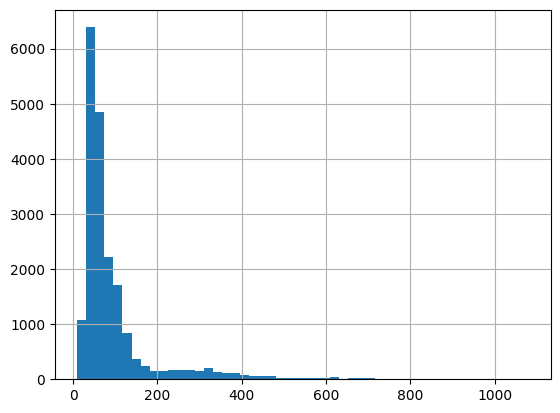

In [31]:
df["Appliances"].hist(bins=50)

# Right-skewed distribution.

# Need to use np.log